In [1]:
!pwd

/mnt/d/blog_in_progress/genAI


In [3]:
#run under conda deepchem env
import os
import re
import random
import torch
import pandas as pd

In [4]:
# csv first column is SMILES, second column is label
def csv_to_smi(csv_file, smi_file):
    """
    Converts a CSV file with SMILES and labels to a .smi file.
    """
    if not os.path.exists(csv_file):
        print(f"File not found: {csv_file}")
        return

    df = pd.read_csv(csv_file)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True) # Shuffle the DataFrame for randomness
    
    if df.shape[1] < 2:
        print("CSV file must have at least two columns: SMILES and label.")
        return
    
    with open(smi_file, 'w') as f:
        for index, row in df.iterrows():
            smiles = row[0]
            #label = row[1]
            #f.write(f"{smiles} {label}\n")
            f.write(f"{smiles}\n")
    
    print(f"Converted {csv_file} to {smi_file}")
    
def split_smi_file(input_file, train_file, valid_file, ratio=0.8):
    """
    Randomly splits a .smi file into train and test files.
    """
    if not os.path.exists(input_file):
        print(f"File not found: {input_file}")
        return

    with open(input_file, 'r') as f:
        lines = f.readlines()
    
    # Remove empty lines
    lines = [line for line in lines if line.strip()]
    
    # Shuffle lines
    random.seed(42) # For reproducibility
    random.shuffle(lines)
    
    split_point = int(len(lines) * ratio)
    train_data = lines[:split_point]
    valid_data = lines[split_point:]
    
    with open(train_file, 'w') as f:
        f.writelines(train_data)
        
    with open(valid_file, 'w') as f:
        f.writelines(valid_data)
        
    print(f"Total lines: {len(lines)}")
    print(f"Train set ({len(train_data)} lines) saved to {train_file}")
    print(f"Valid set ({len(valid_data)} lines) saved to {valid_file}")

In [6]:
csv_to_smi(
    '/mnt/d/blog_in_progress/genAI/CRBN_database_include_covalency.csv',
    '/mnt/d/blog_in_progress/genAI/test_with_covalency/all_dataset.smi'
)
split_smi_file(
    '/mnt/d/blog_in_progress/genAI/test_with_covalency/all_dataset.smi',
    '/mnt/d/blog_in_progress/genAI/test_with_covalency/train_dataset.smi', 
    '/mnt/d/blog_in_progress/genAI/test_with_covalency/valid_dataset.smi',
    0.8
)

Converted /mnt/d/blog_in_progress/genAI/CRBN_database_include_covalency.csv to /mnt/d/blog_in_progress/genAI/test_with_covalency/all_dataset.smi
Total lines: 6587
Train set (5269 lines) saved to /mnt/d/blog_in_progress/genAI/test_with_covalency/train_dataset.smi
Valid set (1318 lines) saved to /mnt/d/blog_in_progress/genAI/test_with_covalency/valid_dataset.smi


/tmp/ipykernel_427232/1292644743.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  smiles = row[0]


In [ ]:
# Load and Check Pre-trained Prior Model (RNN) Smiles Vocabulary and Tokens
model_path = "/home/haolan/REINVENT4/Priors/reinvent.prior"
state = torch.load(model_path, map_location='cpu', weights_only=False)
vocab = state['vocabulary']

tokens = []
if hasattr(vocab, '_tokens'):
    tokens = list(vocab._tokens.keys())
elif hasattr(vocab, 'tokens'):
    tokens = vocab.tokens
elif hasattr(vocab, 'get_tokens'):
    tokens = vocab.get_tokens()
elif hasattr(vocab, 'token_to_idx'):
    tokens = list(vocab.token_to_idx.keys())

# Ensure string tokens
allowed_tokens = set([str(t) for t in tokens])
print(f"Loaded {len(allowed_tokens)} tokens from model.")

Loaded 59 tokens from model.


In [ ]:
# It seems that stereochemistry tokens like '@' and '/' are not in the model's vocabulary, 
# which may cause issues when processing SMILES with stereochemistry...
allowed_tokens

{'#',
 '$',
 '%10',
 '(',
 ')',
 '-',
 '0',
 '1',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '2',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '3',
 '30',
 '31',
 '32',
 '33',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '=',
 'Br',
 'C',
 'Cl',
 'F',
 'N',
 'O',
 'S',
 '[N+]',
 '[N-]',
 '[O-]',
 '[S+]',
 '[n+]',
 '[nH]',
 '^',
 'c',
 'n',
 'o',
 's'}

In [9]:
# Define a regex to tokenize SMILES (approximation based on standard REINVENT regex)
# We want to split the SMILES into chunks and see if each chunk is in allowed_tokens.
# The standard regex is something like:
# token_regex = r"(\[[^\]]+]|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p|\(|\)|\.|=|#|-|\+|\\\\|\/|:|~|@|\?|>|\*|\$|\%[0-9]{2}|[0-9])"
# But we should construct it based on what we see or simply use the fact that if we remove all allowed tokens from the string, nothing should be left.
# However, order matters for greedy matching (e.g. Br vs B).
# So we sort allowed tokens by length descending.
sorted_tokens = sorted(list(allowed_tokens), key=len, reverse=True)
# Escape special regex chars
escaped_tokens = [re.escape(t) for t in sorted_tokens]
pattern = "|".join(escaped_tokens)
regex = re.compile(pattern)

In [11]:
def is_valid_smiles(smiles):
    # Remove all recognized tokens
    # If using re.findall, we get all tokens. Then we join them and compare with original string? 
    # No, because some tokens might be substrings of others if not greedy.
    # But our regex is greedy (alternation with longest first).
    
    # Let's try to match tokens and see if the extracted tokens cover the whole string.
    # Actually, simply replacing all matches with "" and checking if empty is easier.
    
    remainder = regex.sub('', smiles)
    if len(remainder) > 0:
        return False, remainder
    return True, ""

workspace_path = "/mnt/d/blog_in_progress/genAI/test_with_covalency"
files = ["train_dataset.smi", "valid_dataset.smi", "all_dataset.smi"]

for filename in files:
    file_path = os.path.join(workspace_path, filename)
    if not os.path.exists(file_path):
        continue

    print(f"Processing {filename}...")
    with open(file_path, "r") as f:
        lines = f.readlines()
    
    valid_lines = []
    invalid_count = 0
    
    for line in lines:
        smi = line.strip()
        if not smi: continue
        parts = smi.split()
        smi_part = parts[0]
        
        valid, remainder = is_valid_smiles(smi_part)
        if valid:
            valid_lines.append(smi)
        else:
            invalid_count += 1
            if invalid_count <= 5: # Print first few reasons
                 print(f"  Invalid SMILES: {smi_part} (Remainder: '{remainder}')")
    
    with open(file_path, "w") as f:
        f.write("\n".join(valid_lines) + "\n")
    
    print(f"  Kept {len(valid_lines)} lines. Removed {invalid_count} lines.")

Processing train_dataset.smi...
  Invalid SMILES: O=C1CC(NC(=O)OCC2CCC[NH2+]2)C(=O)N1 (Remainder: '[H+]')
  Invalid SMILES: O=C1CCC2(CC(c3ccccc3I)=NO2)C(=O)N1 (Remainder: 'I')
  Invalid SMILES: [2H]C([2H])([2H])n1ccc2cc(C(=O)NC3CCC(=O)NC3=O)ccc21 (Remainder: '[H][H][H]')
  Invalid SMILES: [2H]C([2H])([2H])Oc1ccc2cc(C(=O)Nc3ccc4c(c3)CN(C3CCC(=O)NC3=O)C4=O)ccc2c1 (Remainder: '[H][H][H]')
  Invalid SMILES: O=C1CCC(NC(=O)c2ccccc2I)C(=O)N1 (Remainder: 'I')
  Kept 5259 lines. Removed 10 lines.
Processing valid_dataset.smi...
  Invalid SMILES: [NH3+]C1CCC(COC(=O)NC2CCC(=O)NC2=O)CC1 (Remainder: '[H+]')
  Kept 1317 lines. Removed 1 lines.
Processing all_dataset.smi...
  Invalid SMILES: O=C1CC(NC(=O)OCC2CCC[NH2+]2)C(=O)N1 (Remainder: '[H+]')
  Invalid SMILES: [NH3+]Cc1ccc(COC(=O)NC2CCC(=O)NC2=O)cc1 (Remainder: '[H+]')
  Invalid SMILES: O=C1CCC2(CC(c3ccccc3I)=NO2)C(=O)N1 (Remainder: 'I')
  Invalid SMILES: [NH3+]C1CCC(COC(=O)NC2CC(=O)NC2=O)CC1 (Remainder: '[H+]')
  Invalid SMILES: [NH3+]C1CCC(COC(

Processing all_dataset.smi for scaffolds...
Total unique scaffolds: 3745
Top 10 scaffolds:
  Scaffold: O=C1CCC(N2Cc3ccccc3C2=O)C(=O)N1, Count: 195
  Scaffold: O=C1CCC(NC(=O)c2ccccc2)C(=O)N1, Count: 125
  Scaffold: O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1, Count: 124
  Scaffold: O=C1CCC(N2Cc3cc(-c4ccccn4)ccc3C2=O)C(=O)N1, Count: 53
  Scaffold: O=C1CCC(N2Cc3c(cccc3-c3ccccc3)C2=O)C(=O)N1, Count: 46
  Scaffold: O=C1CCC(N2Cc3cc(-c4ccccc4)ccc3C2=O)C(=O)N1, Count: 25
  Scaffold: O=C1NCc2ccccc21, Count: 23
  Scaffold: O=C1CCC(CSc2ccccc2)C(=O)N1, Count: 19
  Scaffold: O=C1CCC(n2cc(-c3ccccc3)nn2)C(=O)N1, Count: 19
  Scaffold: O=C1CCC(N2Cc3c(cccc3-n3ccnn3)C2=O)C(=O)N1, Count: 18


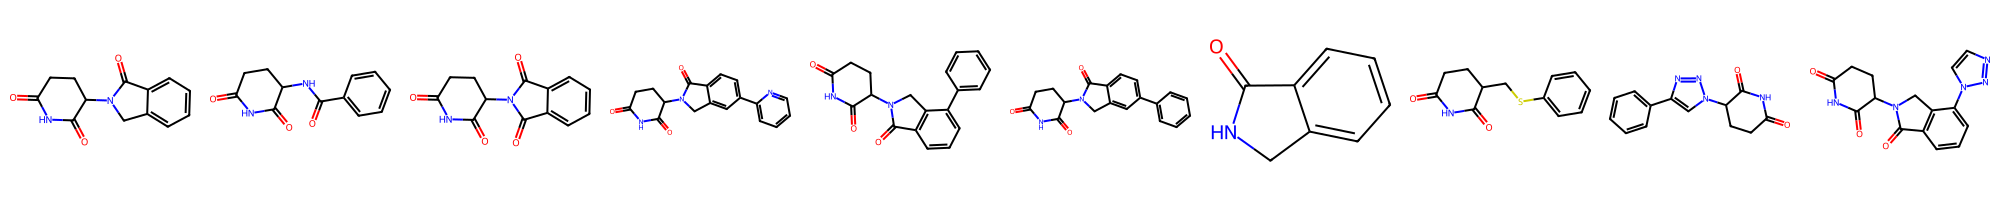

In [ ]:
'''
# check Murcko scaffolds for all datasets
import os
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
def get_murcko_scaffold(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold, isomericSmiles=True)
    except Exception as e:
        print(f"Error processing SMILES: {smiles} - {e}")
        return None

workspace_path = "/mnt/d/blog_in_progress/genAI/test_with_covalency"
files = ["all_dataset.smi"]

scaffold_counts = {}
for filename in files:
    file_path = os.path.join(workspace_path, filename)
    if not os.path.exists(file_path):
        continue

    print(f"Processing {filename} for scaffolds...")
    with open(file_path, "r") as f:
        lines = f.readlines()
    
    for line in lines:
        smi = line.strip()
        if not smi: continue
        parts = smi.split()
        smi_part = parts[0]
        
        scaffold = get_murcko_scaffold(smi_part)
        if scaffold is not None:
            scaffold_counts[scaffold] = scaffold_counts.get(scaffold, 0) + 1

print(f"Total unique scaffolds: {len(scaffold_counts)}")
# Print top 10 scaffolds
top_scaffolds = sorted(scaffold_counts.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 scaffolds:")
for scaffold, count in top_scaffolds:
    print(f"  Scaffold: {scaffold}, Count: {count}")

Draw.MolsToImage([Chem.MolFromSmiles(scaffold) for scaffold, _ in top_scaffolds])
'''